# UniSim — Visual Experiments

> **Goal:** See how a unified action-in-video-out interface and a shared action space let one simulator span many domains.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Action-in, video-out** | What is the unified interface that frames every interaction the same way? |
| 2 | **Unified action space** | Can motor, language, and camera-motion actions map to one conditioning? |
| 3 | **Autoregressive rollout** | How does long-horizon simulation stay consistent, and where does it drift? |
| 4 | **Multi-domain transfer** | Does training on diverse domains beat a single-domain simulator? |

---
**Linked theory:** [research/09-unisim.md](../research/09-unisim.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(0)
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})


def render(pos, S=20):
    yy, xx = np.mgrid[0:S, 0:S]
    return np.exp(-(((xx - pos[0]) ** 2 + (yy - pos[1]) ** 2) / 4.0))


print('Setup complete.')

Setup complete.


---
## Experiment 1: Action-in, video-out

**Question:** UniSim frames every interaction as 'given the current scene and an action, predict the next scene'. What does that interface look like on a toy scene?

We render an object, apply an action (a motion), and render the resulting frame — the action-in-video-out unit UniSim learns.

In [2]:
pos = np.array([6.0, 10.0])
action = np.array([7.0, -3.0])   # move right and up
frame_t = render(pos)
frame_next = render(pos + action)
print(f'scene at {pos}, action {action} -> scene at {pos + action}')

scene at [ 6. 10.], action [ 7. -3.] -> scene at [13.  7.]


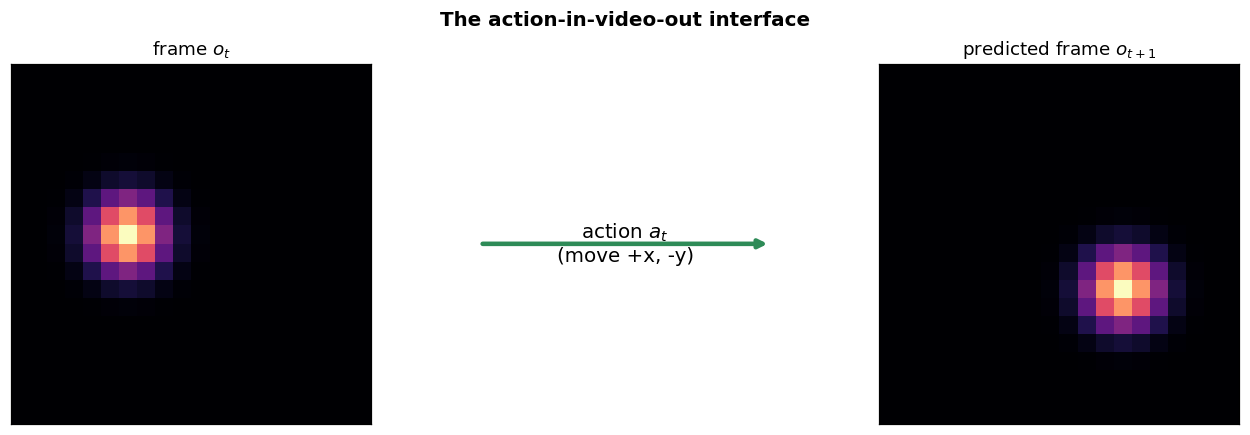

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('The action-in-video-out interface', fontsize=13, fontweight='bold')

axes[0].imshow(frame_t, cmap='magma', origin='lower'); axes[0].set_title('frame $o_t$')
axes[1].axis('off')
axes[1].annotate('action $a_t$\n(move +x, -y)', (0.5, 0.5), ha='center', va='center', fontsize=13)
axes[1].annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5), arrowprops=dict(arrowstyle='-|>', lw=3, color='seagreen'))
axes[2].imshow(frame_next, cmap='magma', origin='lower'); axes[2].set_title('predicted frame $o_{t+1}$')
for ax in (axes[0], axes[2]):
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The object in frame $o_t$ moves according to the action and appears at its new location in $o_{t+1}$ — the simulator's basic prediction unit.
2. **Why it looks this way:** UniSim conditions a generative (video diffusion) model on the past frame(s) and an action, then renders the next frame; here we use a simple deterministic renderer to show the interface.
3. **Key takeaway:** Almost any interaction can be cast as action-in-video-out, which is the single interface that lets UniSim absorb wildly different data sources.

---
## Experiment 2: Unified action space

**Question:** UniSim accepts actions in many modalities — motor controls, language ('move right'), camera-motion-derived. Can these heterogeneous inputs map to one shared action conditioning?

We define three modality encoders that all map their input to a common 2-D action vector, then show they produce the same next frame.

In [4]:
# the same intended action 'move right by 7' expressed three ways
def from_motor(vec):           # already a control vector
    return np.array(vec, float)

def from_language(text):       # parse a phrase
    table = {'move right': [7, 0], 'move up': [0, -7], 'move left': [-7, 0]}
    return np.array(table[text], float)

def from_camera(flow):         # mean optical flow -> action
    return np.array(flow).mean(0)

motor_a = from_motor([7, 0])
lang_a = from_language('move right')
cam_a = from_camera([[6.5, 0.2], [7.5, -0.2], [7.0, 0.0]])
pos = np.array([6.0, 10.0])
frames = {m: render(pos + a) for m, a in [('motor', motor_a), ('language', lang_a), ('camera', cam_a)]}
print('decoded actions ->', {'motor': motor_a, 'language': lang_a, 'camera': np.round(cam_a, 1)})

decoded actions -> {'motor': array([7., 0.]), 'language': array([7., 0.]), 'camera': array([7., 0.])}


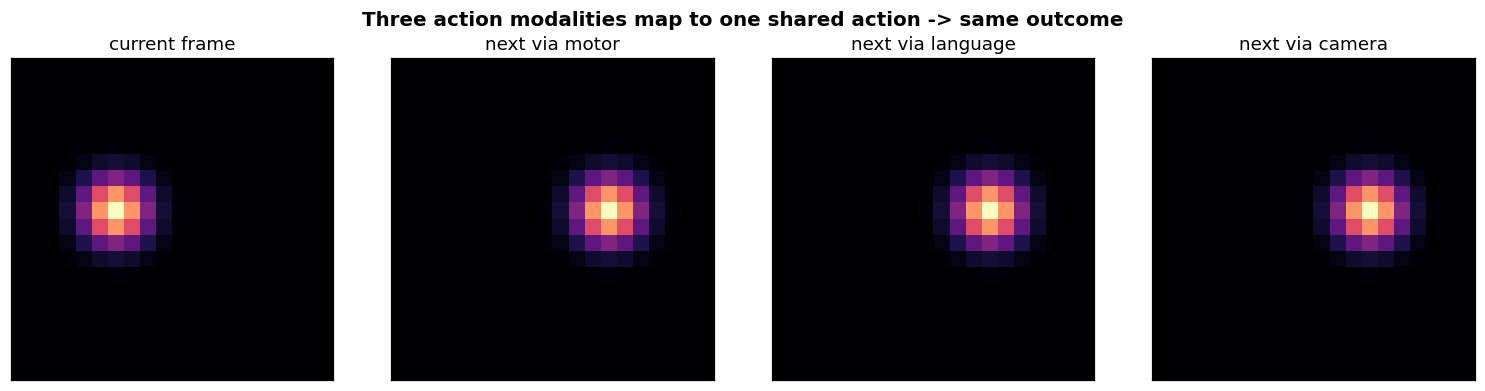

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
fig.suptitle('Three action modalities map to one shared action -> same outcome', fontsize=13, fontweight='bold')

axes[0].imshow(render(pos), cmap='magma', origin='lower'); axes[0].set_title('current frame')
for ax, (m, fr) in zip(axes[1:], frames.items()):
    ax.imshow(fr, cmap='magma', origin='lower'); ax.set_title(f'next via {m}')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** A motor vector, the phrase 'move right', and camera optical-flow all decode to (approximately) the same action, so the predicted next frame is the same across all three modalities.
2. **Why it looks this way:** Each modality has its own small encoder into a *common* action space; once there, the simulator does not care where the action came from. This is how UniSim trains on label-free video (camera-motion actions) alongside robot motor data.
3. **Key takeaway:** A shared action space is the second unifier (after action-in-video-out) that lets one model learn from radically different data sources.

---
## Experiment 3: Autoregressive rollout

**Question:** UniSim simulates long horizons by feeding its own predictions back in. How consistent is that rollout, and where does it drift?

We roll out a sequence of actions, rendering each frame, and track how an imperfect simulator's predicted position drifts from the true one over the horizon.

In [6]:
np.random.seed(3)

actions = [np.array([2.5, 0]), np.array([0, 2.0]), np.array([2.0, 1.5]),
           np.array([1.0, -2.5]), np.array([-2.0, 1.0]), np.array([2.0, 1.0])]
true_pos = [np.array([3.0, 3.0])]
sim_pos = [np.array([3.0, 3.0])]
for a in actions:
    true_pos.append(true_pos[-1] + a)
    sim_pos.append(sim_pos[-1] + a + 0.6 * np.random.randn(2))   # imperfect prediction each step
frames = [render(p) for p in sim_pos]
errs = [np.linalg.norm(s - t) for s, t in zip(sim_pos, true_pos)]
print('rollout position error by step:', np.round(errs, 2))

rollout position error by step: [0.   1.1  1.42 1.44 1.71 1.95 1.2 ]


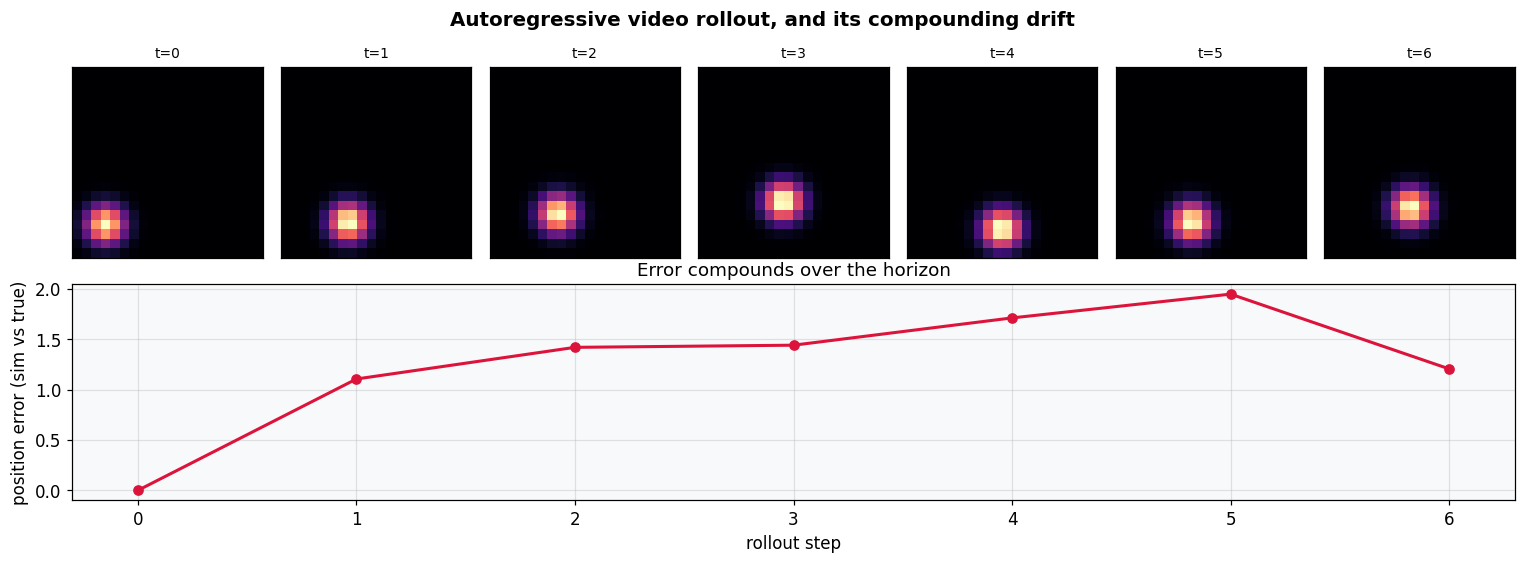

In [7]:
fig = plt.figure(figsize=(14, 5.2))
fig.suptitle('Autoregressive video rollout, and its compounding drift', fontsize=13, fontweight='bold')

for i, fr in enumerate(frames):
    ax = fig.add_subplot(2, len(frames), i + 1)
    ax.imshow(fr, cmap='magma', origin='lower'); ax.set_title(f't={i}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

ax2 = fig.add_subplot(2, 1, 2)
ax2.plot(errs, '-o', color='crimson', lw=2)
ax2.set_xlabel('rollout step'); ax2.set_ylabel('position error (sim vs true)')
ax2.set_title('Error compounds over the horizon')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The top strip is a consistent simulated video — the object moves coherently frame to frame. The bottom curve shows the position error growing as the rollout lengthens.
2. **Why it looks this way:** Each step feeds the previous prediction back in, so small per-step errors accumulate; the rollout stays locally consistent but slowly drifts from the true trajectory — the compounding-error problem of all autoregressive world models.
3. **Key takeaway:** UniSim achieves long, consistent simulations by conditioning on history, but like every rollout it accumulates error, bounding reliable horizon length.

---
## Experiment 4: Multi-domain transfer

**Question:** UniSim's payoff is learning from many domains at once. Does a model trained on diverse domains handle each, where a single-domain model fails on the others?

We define three domains with different dynamics (translate, rotate, scale) and compare a single-domain predictor against a domain-conditioned universal one.

In [8]:
torch.manual_seed(4)


def step_domain(s, a, dom):
    if dom == 0:      # translate
        return s + a
    if dom == 1:      # rotate by a[0]
        ang = a[:, 0]; c, sn = np.cos(ang), np.sin(ang)
        return np.stack([c * s[:, 0] - sn * s[:, 1], sn * s[:, 0] + c * s[:, 1]], 1)
    return s * (1 + 0.3 * a)   # scale


def gen(dom, n=3000):
    s = np.random.randn(n, 2); a = 0.5 * np.random.randn(n, 2)
    return s, a, step_domain(s, a, dom)


def make_set(domains):
    S, A, Snext, D = [], [], [], []
    for dom in domains:
        s, a, sn = gen(dom)
        S.append(s); A.append(a); Snext.append(sn); D.append(np.full(len(s), dom))
    oh = np.eye(3)[np.concatenate(D)]
    return (torch.tensor(np.concatenate(S), dtype=torch.float32),
            torch.tensor(np.concatenate(A), dtype=torch.float32),
            torch.tensor(np.concatenate(Snext), dtype=torch.float32),
            torch.tensor(oh, dtype=torch.float32))


def train_pred(use_domain, train_domains):
    S, A, Sn, OH = make_set(train_domains)
    in_dim = 4 + (3 if use_domain else 0)
    net = nn.Sequential(nn.Linear(in_dim, 64), nn.SiLU(), nn.Linear(64, 2))
    opt = torch.optim.Adam(net.parameters(), lr=3e-3)
    for _ in range(1500):
        idx = torch.randint(0, len(S), (256,))
        x = torch.cat([S[idx], A[idx]] + ([OH[idx]] if use_domain else []), 1)
        loss = ((net(x) - Sn[idx]) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return net


single = train_pred(False, [0])           # trained only on translate
universal = train_pred(True, [0, 1, 2])   # trained on all, domain-conditioned


def eval_dom(net, dom, use_domain):
    S, A, Sn, OH = make_set([dom])
    x = torch.cat([S, A] + ([OH] if use_domain else []), 1)
    with torch.no_grad():
        return ((net(x) - Sn) ** 2).mean().item()


single_err = [eval_dom(single, d, False) for d in range(3)]
uni_err = [eval_dom(universal, d, True) for d in range(3)]
print('single-domain MSE per domain:', np.round(single_err, 3))
print('universal     MSE per domain:', np.round(uni_err, 3))

single-domain MSE per domain: [0.    0.475 0.273]
universal     MSE per domain: [0.005 0.029 0.005]


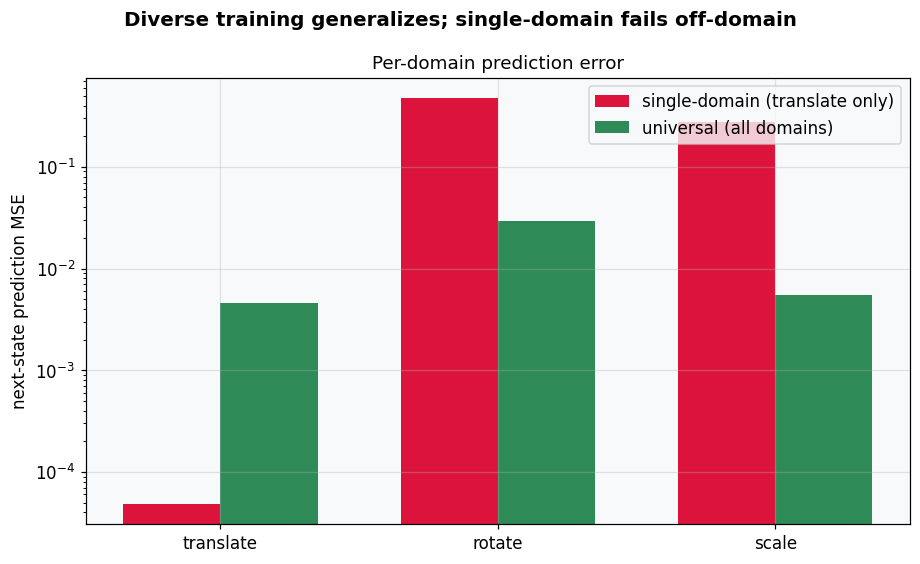

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
fig.suptitle('Diverse training generalizes; single-domain fails off-domain', fontsize=13, fontweight='bold')

labels = ['translate', 'rotate', 'scale']
x = np.arange(3); w = 0.35
ax.bar(x - w/2, single_err, w, color='crimson', label='single-domain (translate only)')
ax.bar(x + w/2, uni_err, w, color='seagreen', label='universal (all domains)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('next-state prediction MSE'); ax.set_yscale('log')
ax.set_title('Per-domain prediction error')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The single-domain model (red) predicts the translate domain it trained on but has high error on rotate and scale. The universal model (green) achieves low error on all three.
2. **Why it looks this way:** A model trained on one dynamics learns only that rule; off-domain it applies the wrong transform. The domain-conditioned universal model sees all dynamics and uses the conditioning to switch behaviour — learning a single simulator that covers every domain.
3. **Key takeaway:** With a unified interface and conditioning, one simulator absorbs diverse domains and transfers across them — UniSim's central promise and a direct analogue of a multi-domain latent framework.


---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Action-in, video-out | Every interaction is framed as predict-next-scene-given-action — one interface for all data. |
| 2. Unified action space | Motor, language, and camera-motion actions map to one conditioning, enabling label-free data. |
| 3. Autoregressive rollout | Feeding predictions back gives consistent long simulations that slowly drift (compounding error). |
| 4. Multi-domain transfer | A domain-conditioned model trained on diverse dynamics handles all; single-domain fails off-domain. |

### Connection to the broader theory

UniSim is the universal, pixel-space end of the world-model spectrum: a [video-diffusion](../../09-discrete-latent/research/08-gaia-1.md) simulator unified by an action-in-video-out interface and a shared action space. Against the compact-latent [LeWM](../research/08-lewm.md) and the planning-centric [Dreamer](../research/01-dreamerv1.md)/[MuZero](../research/05-muzero.md), it shows the multi-domain extreme a latent framework must accommodate. With this, the World Models & VLA tier is complete; the remaining supplementary tiers cover interpretability tooling and the supporting mathematics.